Question 1  
(a) Price Prediction  
Price prediction is about estimating what the market price will be based on historical patterns and external forces. The firm takes the prices
Examples:
- Stock trading
- Commodity markets
- Foreign exchange and interest rates
In these environments, firms do not set prices—they forecast them.
Prediction is supervised learning with labels

Price Optimization  
Price optimization is about selecting the price that maximizes a business objective, given predicted customer behavior.
The firm makes the price
Examples:
- E‑commerce
- Airlines and hotels
- Digital advertising platforms  
Price Optimization isa decision problem for maximizing profit. There is no one answers. It depends on additional factors

In these markets, firms actively influence demand through pricing decisions.
Directly Predicting an “Optimal Price” Is Wrong- There is no  optimal price in the data.
The data only tells you how customers responded to past prices, not which price would be the best.  
Instead, AI models predict based:
- Probability of purchase
- Demand at a given price
- Elasticity
- Expected revenue or profit conditional on price
the model estimates using the formula :  
 ŷ = P(buy | user, product, context, price)  

Then the firm chooses to maximize the profit:  
Hence
- AI predicts customer response.
- The business makes the pricing decision.
That’s why the optimal price is a decision output.

(b) The RIGHT  price depends entirely on the firm’s objective function.
Different objectives naturally lead to different optimal prices.
1. Short‑Term Profit Maximization  
Choose price p to maximize:(p−c)×P(buy∣p)  
This often pushes prices higher, especially when demand is inelastic.For example in a city which has no major airline hubs and fewer airlines operating . An Indianapolis airport might have higher prices than chicago airport
2. Revenue Maximization  
The firm may lower prices to increase volume, even if margins shrink. for example Southwest Airlines, Spirit Airlines, or Frontier Airlines might reduce price competitive leisure routes like chicago to lasvegas even if profit per passenger is small. They benefit from higher passengers, additional revenue and better aircraft utilization
3. Long‑Term Customer Value  
The firm may intentionally set lower prices today to:
- Acquire new customers
- Improve retention
- Build loyalty
- Encourage repeat purchases  
For example Major carriers like Delta Air Lines, American Airlines, and United Airlines might Offers bonus miles for first-time customers,gives discounted fares to students or young professionals because longterm they  might join the loyalty program, accumulate miles, use cobranded cards and become less price sensitive.

Question 2

## Build a logistic model to predict purchase

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
from sklearn.metrics import brier_score_loss,confusion_matrix

# Load the dataset
data = pd.read_csv("pricing.csv")

# Replace extra spaces with underscore in the column
data = data.rename(columns=lambda c: c.strip().replace(" ", "_"))

# Convert Purchase_probability column into integers
data["Purchase_Probability"] = data["Purchase_Probability"].astype(int)

# Split Training data 70%/30%
train_df, test_df = train_test_split(data,test_size=0.30,    random_state=42,    stratify=data["Purchase_Probability"] )

# Define the logistic regression formula
formula = "Purchase_Probability ~ Price + Discount + Customer_Age + Review_Rating + C(Product_Category) + C(Customer_Gender) + C(Payment_Method) + C(Shipping_Type)"

# Fit the logistic regression model
model = smf.logit(formula=formula, data=train_df).fit()

# Print the model summary
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.009007
         Iterations 18
                            Logit Regression Results                            
Dep. Variable:     Purchase_Probability   No. Observations:                 1430
Model:                            Logit   Df Residuals:                     1416
Method:                             MLE   Df Model:                           13
Date:                  Sun, 15 Feb 2026   Pseudo R-squ.:                  0.9870
Time:                          19:47:25   Log-Likelihood:                -12.880
converged:                         True   LL-Null:                       -991.20
Covariance Type:              nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                            

##Predicted Probabilities and Evalution of Performance on Test

In [2]:
#  Predicted probabilities of purchase on test set
test_pred_prob = model.predict(test_df)

# Threshold at 0.5
test_pred_class = (test_pred_prob >= 0.5).astype(int)

# Compute confusion matrix
conf_matrix = confusion_matrix(test_df["Purchase_Probability"], test_pred_class)
tn, fp, fn, tp = conf_matrix.ravel()
conf_matrix_tp_topleft = np.array([[tp, fn],
                                    [fp, tn]])

brier = brier_score_loss(test_df["Purchase_Probability"], test_pred_prob)

print("\n====================")
print("LOGIT MODEL (TEST) - PERFORMANCE")
print("====================")
print("ROC-AUC   :", roc_auc_score(test_df["Purchase_Probability"], test_pred_prob))
print("Log Loss  :", log_loss(test_df["Purchase_Probability"], test_pred_prob))
print("Accuracy  :", accuracy_score(test_df["Purchase_Probability"], test_pred_class))
print("Confusion Matrix:", conf_matrix_tp_topleft)
print("Brier Score:", round(brier, 2))


LOGIT MODEL (TEST) - PERFORMANCE
ROC-AUC   : 0.9995225413532239
Log Loss  : 0.04852999482689239
Accuracy  : 0.99185667752443
Confusion Matrix: [[302   5]
 [  0 307]]
Brier Score: 0.01


##GradientBoosting

In [3]:
# FEATURES / TARGET
#Drop the predicated variable  and ID fields and timestamp
drop_cols = ["Purchase_Probability", "Transaction_ID", "Product_ID", "Customer_ID", "Purchase_Timestamp"]
X = data.drop(columns=drop_cols)
y = data["Purchase_Probability"].astype(int)

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["Purchase_Probability"]

X_test  = test_df.drop(columns=drop_cols)
y_test  = test_df["Purchase_Probability"]


# COLUMN TYPES
# Categorical columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
# Numerical columns
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numerical columns  :", num_cols)

#  PREPROCESSOR (on train)
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop"
)

# GBT MODEL
gbt = GradientBoostingClassifier(
    learning_rate=0.1,
    n_estimators=100,
    max_depth=4,
    random_state=1
)

# PIPELINE
gbt_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("gbt", gbt)
])

# FIT ON TRAIN
gbt_pipe.fit(X_train, y_train)

#  EVALUATE ON TEST
test_prob = gbt_pipe.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, test_pred)
tn, fp, fn, tp = conf_matrix.ravel()
conf_matrix_tp_topleft = np.array([[tp, fn],
                                    [fp, tn]])

brier = brier_score_loss(y_test, test_prob)

print("\n====================")
print("GBT (TEST) - PERFORMANCE")
print("====================")
print("ROC-AUC  :", (roc_auc_score(y_test, test_prob)))
print("Log Loss :", log_loss(y_test, test_prob))
print("Accuracy :", accuracy_score(y_test, test_pred))
print("Confusion Matrix:", conf_matrix_tp_topleft)
print("Brier Score:", round(brier, 2))

# SCORE EVERYONE (for deciles / Mail flags)
data["predicted_prob_gbt"] = gbt_pipe.predict_proba(X)[:, 1]

Categorical columns: ['Product_Category', 'Customer_Gender', 'Payment_Method', 'Shipping_Type']
Numerical columns  : ['Price', 'Discount', 'Customer_Age', 'Review_Rating']

GBT (TEST) - PERFORMANCE
ROC-AUC  : 0.997124637927193
Log Loss : 0.07298061209641843
Accuracy : 0.9690553745928339
Confusion Matrix: [[297  10]
 [  9 298]]
Brier Score: 0.02


In [4]:
data["decile_gbt"] = 9 - pd.qcut(data["predicted_prob_gbt"], 10, labels=False, duplicates="drop")

reverse_decile_summary = data.groupby("decile_gbt").agg(
    total_responses=("Purchase_Probability", "sum"),
    response_rate=("Purchase_Probability", "mean")
).reset_index()
reverse_decile_summary["response_rate"] *= 100
print(reverse_decile_summary)

breakeven_response_rate = 1/16
data["Mail_gbt"] = (data["predicted_prob_gbt"] >= breakeven_response_rate).astype(int)

summary = data.groupby("Mail_gbt").agg(
    number_of_customers=("Mail_gbt", "size"),
    average_predicted_prob=("predicted_prob_gbt", "mean"),
    total_responses=("Purchase_Probability", "sum"),
    response_rate=("Purchase_Probability", "mean"),
).reset_index()
summary["response_rate"] *= 100
print(summary)


   decile_gbt  total_responses  response_rate
0           0              205     100.000000
1           1              204     100.000000
2           2              203     100.000000
3           3              205     100.000000
4           4              195      95.588235
5           5               10       4.878049
6           6                0       0.000000
7           7                0       0.000000
8           8                0       0.000000
9           9                0       0.000000
   Mail_gbt  number_of_customers  average_predicted_prob  total_responses  \
0         0                  922                0.009404                2   
1         1                 1122                0.902269             1020   

   response_rate  
0       0.216920  
1      90.909091  


##CREATE A EXCEL SPREADSHEET WITH PURCHASE PROBABILITY COLUMN

In [5]:

# Add Puchase probabiltiy column and export csv
# ==========================================

# Drop the same non-feature columns as before
X_all = data.drop(columns=drop_cols)

# Predict probabilities for ALL rows
data["predicted_purchase_probability"] = gbt_pipe.predict_proba(X_all)[:, 1]

# Export to CSV
data.to_csv("pricing_with_purchase_probability.csv", index=False)

print("CSV file with probabilities created successfully!")


CSV file with probabilities created successfully!


##CALCULATE PRICE OPTIMIZATION FOR EACH CATEGORY using excel spreasheet (So that the user does not have to go to the code to change the variable price for each category)

In [6]:
# Load excel file containing variable cost rates for each category

cost_df = pd.read_excel("Variable Cost for Category.xlsx")

# Clean column names
cost_df.columns = cost_df.columns.str.strip()

cost_df["Product_Category"] = cost_df["Product_Category"].astype(str).str.strip()
cost_df["Variable_Cost"] = pd.to_numeric(cost_df["Variable_Cost"], errors="coerce")
print(cost_df)
print("Max cost value:", cost_df["Variable_Cost"].max())
# Build dict: {"Books": 0.55, "Clothing": 0.65, ...}
cost_rate = dict(zip(cost_df["Product_Category"], cost_df["Variable_Cost"]))

print("Loaded cost_rate:", cost_rate)


data["Price_Shown"] = data["Price"] - data["Discount"]

# Create a sensible grid range per category
price_grid_by_cat = {}
for cat in data["Product_Category"].unique():
    # find the price for each category
    dcat = data.loc[data["Product_Category"] == cat, "Price_Shown"].dropna()
    # Get the 5th and 95th Percentile for each category
    lo, hi = np.percentile(dcat, [5, 95])
    # 60 candidate prices which is the optimal approximation choosen
    price_grid_by_cat[cat] = np.linspace(lo, hi, 60)


# Compute expected profit for a given category and candidate shown price
# X_temp is created with same columns and Price /Discount is overwritten

def expected_profit_for_price(category, candidate_price_shown):
    dcat = data[data["Product_Category"] == category].copy()

    # Build feature frame for X_temp
    X_temp = dcat.drop(columns=drop_cols).copy()


    # Discount = 0
    # shown price = Price - Discount
    #Shown Price = candidate
    X_temp["Discount"] = 0.0
    X_temp["Price"] = float(candidate_price_shown)

    # Predict purchase probabilities under this candidate price
    p_hat = gbt_pipe.predict_proba(X_temp)[:, 1]

    # Expected profit per row
    # Profit=(Price−Variable Cost)×Volume−Fixed Cost
    margin = (1 - cost_rate[category]) * float(candidate_price_shown)
    exp_profit = p_hat * margin

    # Return average expected profit
    return exp_profit.mean()

# best price per category

opt_results = []

for cat in sorted(data["Product_Category"].unique()):
    if cat not in cost_rate:
        print(f"Skipping {cat} (no cost rate provided).")
        continue

    grid = price_grid_by_cat[cat]
    profits = [expected_profit_for_price(cat, p) for p in grid]

    best_idx = int(np.argmax(profits))
    best_price = float(grid[best_idx])
    best_profit = float(profits[best_idx])

    opt_results.append({
        "Product_Category": cat,
        "Optimal_Price_Shown": best_price,
        "Max_Avg_Expected_Profit": best_profit
    })

opt_df = pd.DataFrame(opt_results).sort_values("Max_Avg_Expected_Profit", ascending=False)
print("\n=== Q3(a) Optimal Prices by Category (GBT model) ===")
print(opt_df)

# save results
opt_df.to_csv("q3_optimal_prices_by_category.csv", index=False)

  Product_Category  Variable_Cost
0            Books           0.55
1         Clothing           0.65
2   Home & Kitchen           0.70
3      Electronics           0.85
Max cost value: 0.85
Loaded cost_rate: {'Books': 0.55, 'Clothing': 0.65, 'Home & Kitchen': 0.7, 'Electronics': 0.85}

=== Q3(a) Optimal Prices by Category (GBT model) ===
  Product_Category  Optimal_Price_Shown  Max_Avg_Expected_Profit
0            Books           684.001017               116.338500
1         Clothing           684.943898                72.975316
3   Home & Kitchen           555.589559                70.314595
2      Electronics           548.583136                33.716275


##CALCULATE PRICE OPTIMIZATION FOR EACH CATEGORY The same code has been also rewritten to hardcode the variable cost

In [7]:
# Load hard code the category
drop_cols = ["Purchase_Probability", "Transaction_ID", "Product_ID", "Customer_ID", "Purchase_Timestamp"]



#Display Price shown = Price - Discount
cost_rate = {
    "Books": 0.55,
    "Clothing": 0.65,
    "Home & Kitchen": 0.70,
    "Electronics": 0.85
}

print(cost_rate)

data["Variable_Cost_Rate"] = data["Product_Category"].map(cost_rate)
data["Price_Shown"] = data["Price"] - data["Discount"]

print ("\n")
price_grid_by_cat = {}
for cat in data["Product_Category"].unique():
    dcat = data.loc[data["Product_Category"] == cat, "Price_Shown"].dropna()
    lo, hi = np.percentile(dcat, [5, 95])
    price_grid_by_cat[cat] = np.linspace(lo, hi, 60)

def expected_profit_for_price(category, candidate_price_shown):
    dcat = data[data["Product_Category"] == category].copy()
    X_temp = dcat.drop(columns=drop_cols).copy()

    X_temp["Discount"] = 0.0
    X_temp["Price"] = float(candidate_price_shown)

    p_hat = gbt_pipe.predict_proba(X_temp)[:, 1]
    margin = (1 - cost_rate[category]) * float(candidate_price_shown)

    return (p_hat * margin).mean()

# best price per category
opt_results = []
for cat in sorted(data["Product_Category"].unique()):
    if cat not in cost_rate:
        print(f"Skipping {cat} (no cost rate provided).")
        continue

    grid = price_grid_by_cat[cat]
    profits = [expected_profit_for_price(cat, p) for p in grid]

    best_idx = int(np.argmax(profits))
    opt_results.append({
        "Product_Category": cat,
        "Variable Cost Rate": cost_rate[cat],
        "Optimal_Price_Shown": float(grid[best_idx]),
        "Max_Avg_Expected_Profit": float(profits[best_idx])
    })

opt_df = pd.DataFrame(opt_results).sort_values("Max_Avg_Expected_Profit", ascending=False)
print(opt_df)

{'Books': 0.55, 'Clothing': 0.65, 'Home & Kitchen': 0.7, 'Electronics': 0.85}


  Product_Category  Variable Cost Rate  Optimal_Price_Shown  \
0            Books                0.55           684.001017   
1         Clothing                0.65           684.943898   
3   Home & Kitchen                0.70           555.589559   
2      Electronics                0.85           548.583136   

   Max_Avg_Expected_Profit  
0               116.338500  
1                72.975316  
3                70.314595  
2                33.716275  


##EXPECTED PROFIT VS PRICE GRAPH

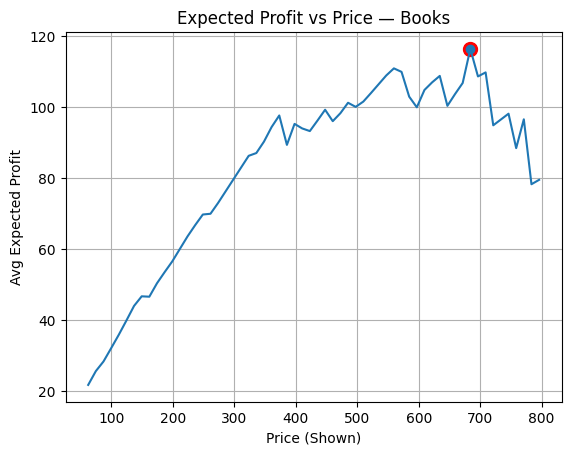

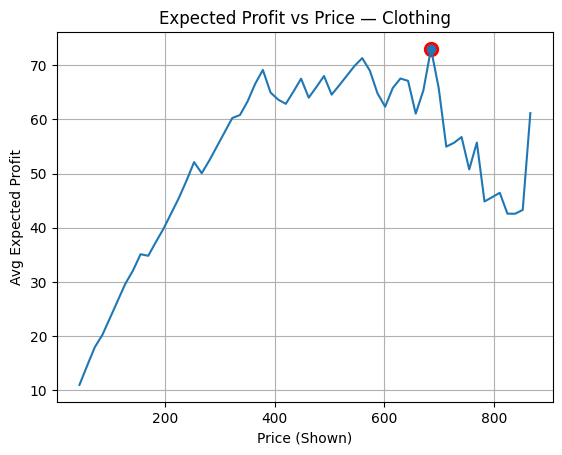

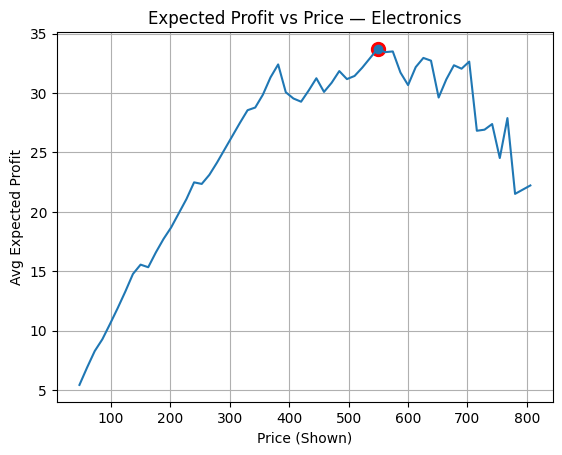

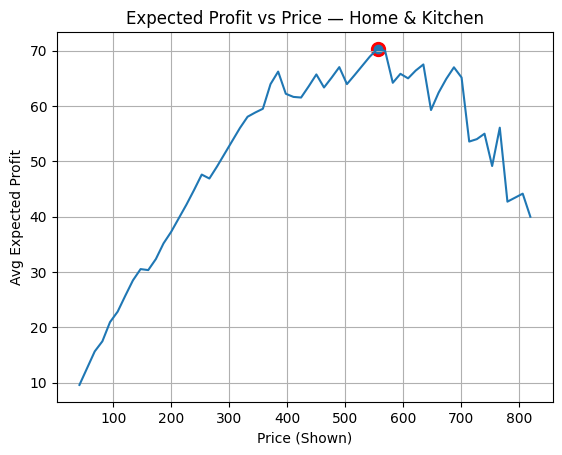

In [8]:

#Initialize

data["Product_Category"] = data["Product_Category"].astype(str).str.strip()
data["PriceShown"] = data["Price"] - data["Discount"]

categories = sorted(data["Product_Category"].unique())


#Enter cost rate for different categories
cost_rate_raw = {
    "Books": 0.55,
    "Clothing": 0.65,
    "Home & Kitchen": 0.70,
    "Electronics": 0.85
}
cost_rate = {k.strip().lower(): v for k, v in cost_rate_raw.items()}

#Build the price grid
price_grid = {}
for cat in categories:
    shown = data.loc[data["Product_Category"] == cat, "PriceShown"]
    p_low = shown.quantile(0.05)
    p_high = shown.quantile(0.95)

    # 60 candidate prices from 5th to 95th percentile
    price_grid[cat] = np.linspace(p_low, p_high, 60)


#Plot the profit curve for each category
for cat in categories:
    sub = data[data["Product_Category"] == cat].copy()

    prices = price_grid[cat]
    profits = []

    # normalized key for cost lookup
    cat_key = cat.strip().lower()

    if cat_key not in cost_rate:
        raise KeyError(
            f"Category '{cat}' not found in cost_rate. "
            f"Available cost_rate keys: {sorted(cost_rate.keys())}"
        )

    for candidate_price in prices:
        temp = sub.copy()

        # Optimize SHOWN price by setting Discount=0 and Price=candidate_price
        temp["Discount"] = 0
        temp["Price"] = candidate_price

        # Predict purchase probability
        X_temp = temp.drop(columns=drop_cols)
        p_hat = gbt_pipe.predict_proba(X_temp)[:, 1]

        # Expected profit = E[purchase] * margin
        margin = (1 - cost_rate[cat_key]) * candidate_price
        profits.append((p_hat * margin).mean())  # avg expected profit per transaction

    # Display the optimum point
    best_idx = int(np.argmax(profits))
    best_price = float(prices[best_idx])
    best_profit = float(profits[best_idx])

    # Plot
    plt.figure()
    plt.scatter(best_price, best_profit, color="red", s=100)
    plt.plot(prices, profits)
    plt.scatter(best_price, best_profit)
    plt.xlabel("Price (Shown)")
    plt.ylabel("Avg Expected Profit")
    plt.title(f"Expected Profit vs Price — {cat}")
    plt.grid(True)
    plt.show()



**Question 2**

I used logistic regression/gradient boosting to estimate purchase probability. Logisitic regression is well suited for  this problem because the outcome variable purchase probability is binary. This gives exactly what we need for price optimization-the purchase probability at different price points.

Logistic regression
Pros:  
Logistic model produces probability and not just classifications essential for computing expected profit at each candidate price.  
It handles categorical variables.  
Coefficents show how price discounts and other attributes which shift the purchase likelihood.  
The model outputs accurate probability estimates and not arbitary scores. It aligns with the expected profit.  
It is stable,transparent and easy to validate and explain.

Gradient boosting
Pros
captures non linear relationship as customer response to a purchase is non linear
This can capture  complex non linear effects
It has strong prediction accuracty

Cons
It is difficult to intrepert

We could also random forest or neural networks for this problem.

**Choice of Features:**

The variables chosen were price, discount, Product_category, Review_rating, Customer_age, Customer_Gender, payment_method, Shipping_type.

I excluded Transaction_id, Customer_id, Product_id and purchase_timestamp since they do not create a decision variable.  

**Numerical Features:**  
Price -  It affects demand and elasticity.  
Discount - It affects demand and elasticity.  
Customer_age - It gives the demographics of the customer.
Review_Rating - This could go in both numerical and categorical but I put it numerical to avoid overfitting.  

**Categorical Features:**
Shipping_Type - This reflects the urgency of the purchase.  
Payment_Method - This shows the purchasing preferences of the customers.  
Customer_Gender - It gives the demographics of the customer.
Product_Category - It is major decision point on which category it is.  

**Model Peformance - Logistic Regression**  
ROC-AUC   : 0.9995225413532239  
Log Loss  : 0.04852999482689239  
Accuracy  : 0.99185667752443  
Confusion Matrix:   
[[302   5]  
[  0 307]]

Brier Score: 0.01  

The model performance metrics are pretty strong. The ROC of 0.9995 can perfectly rank buyers versus non-buyers. This is rare in a real world purchase data.  
The accuracy of the model is 99.1%.  
The confusion matrix reflects 302 TN, 307 TP and 5 FP. There are no false negatives which means the model almost never misclassifies the purchases.  
The log loss is very slow which indicates well calibrated predictions.  
The brier score is very low which is extremely good and suggests excellent calibrations.

Gradient Boosting
====================
GBT (TEST) - PERFORMANCE
====================
ROC-AUC  : 0.997124637927193
Log Loss : 0.07298061209641843
Accuracy : 0.9690553745928339
Confusion Matrix: [[297  10]
 [  9 298]]
Brier Score: 0.02

The ROC, Accuracy is pretty high for Gradient boosting also.
This kind of model results can be **very rare** in realistic pricing data. The reasons could be a potential overfitting, coefficents might be unreliable, there might be limited noise in the dataset.   

But at the same time this kind of scores are very helpful and highly reliable for pricing optimization.



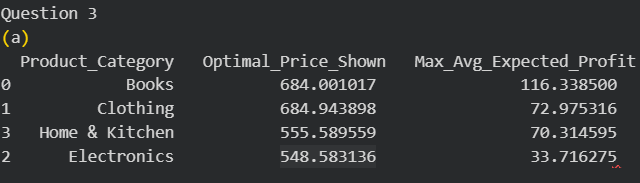

(b) No The profit maximization price is different for short term expected profit and maixmimizing Long term value(LTV).In a short term maximization the prices are chosen to maximize profit.  
ThE firm or the company does not care what happens after the  customers first purchase like repeats, customer loyalty, references.

When the firms objective is long term value the firm cares about customer satisfaction, retention, repeat purchases, building loyalty and acquiring customers. So when they buy the first time - the best price in most cases are lower than profit maximising purchase since it could give us the chance to get a loyal happy customer for life.  

In the above model, Books, Clothing are often repeatable purchases and the companies try to discount these purchases to build a lifetime relationship.  
For example, Barnes and Nobles often give discounts to their loyal customers and special discount to first time buyer.  
Now, Electronics and Home & Kitchen depends on where you buy from.
For example, if you buy from BestBuy they might give you more discount than buying from a company which is online or a one time buy. In those cases for one time buy it might be nearer to the optimal price.

Conclusion:  
The profit maximisation price is optimal for short term profit objective but a firm might choose a different price that might sacrifice some profit to acquire a loyal repeat customer.
